### RQ 4.1 Do the most frequent errors reveal structural or perceptual limitations of VLLMs?

When we analyze why VLLMs fail, the data reveals a clear hierarchy of limitations. The primary bottleneck is not a lack of discipline (structural stability), but a lack of vision (perceptual understanding). Across our fair comparison subset, models failed to understand the emotion 45.08% of the time by either by actively misclassifying the image or by getting stuck in an ambiguous tie where they could not decide. In comparison, they failed to follow the JSON formatting rules only 9.70% of the time. This massive gap is statistically significant ($p < 0.001$, $t = -8.72$), confirming that perceptual blindness is the dominant failure mode and not random.

We also investigated whether structural errors were just a result of us asking for too much, and the answer is mixed. On one hand, switching to a simpler "Discrete" output method did help, cutting the structural error rate nearly in half (from 13.8% to 7.5%). This proves that prompt engineering can stabilize these models to a degree. On the other hand, this fix has limits. Outlier models like minicpm-v:8b and ministral-3:3b continued to crash over 70% of the time regardless of the method, proving that for some architectures, instability is a fundamental defect that cannot be prompted away.

The landscape of VLLM limitations is defined by a "Perceptual Ceiling." Even the most capable models, such as Qwen3-VL, which have effectively solved the structural problem (near 0% error), still hit a hard limit on perceptual accuracy. They follow instructions perfectly but simply cannot distinguish the emotional cues in the image nearly half the time. This suggests that future research should focus less on teaching models how to format JSON and focus more on improving their fundamental visual processing capabilities.

In [85]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
import json
from datasets import load_dataset
from scipy import stats
import os
import math

In [107]:
dataset = load_dataset("Emotion-Aware-AI-Assistant/all_models_results_v1")
df = dataset["train"].to_pandas()

print(f"Full Dataset Shape: {df.shape}")

#We will use 'df_fair' for statistical comparisons (RQ4.1)
#We will use 'df' (full) for failure profiling (RQ4.2)

models_continuous = set(df[df['output_method'] == 'continuous']['model_name'])
models_discrete = set(df[df['output_method'] == 'discrete']['model_name'])

common_models = models_continuous.intersection(models_discrete)
print(f"Models with both methods (Fair Set): {len(common_models)}")

df_fair = df[df['model_name'].isin(common_models)].copy()

print("-" * 30)
print("Columns Available:", df.columns.tolist())
print(df.head())

Full Dataset Shape: (32, 42)
Models with both methods (Fair Set): 8
------------------------------
Columns Available: ['model_name', 'output_method', 'accuracy', 'macro_f1', 'macro_precision', 'macro_recall', 'weighted_f1', 'weighted_precision', 'weighted_recall', 'confusion_matrix_json', 'invalid_counts_json', 'f1_anger', 'f1_disgust', 'f1_fear', 'f1_happiness', 'f1_neutral', 'f1_sadness', 'f1_surprise', 'precision_anger', 'precision_disgust', 'precision_fear', 'precision_happiness', 'precision_neutral', 'precision_sadness', 'precision_surprise', 'recall_anger', 'recall_disgust', 'recall_fear', 'recall_happiness', 'recall_neutral', 'recall_sadness', 'recall_surprise', 'wrong_format', 'emotion_refused', 'emotion_not_listed', 'total_time', 'total_time_hours', 'mean_time', 'response_time_std', 'response_time_mode', 'tie_counts_json', 'method']
        model_name output_method  accuracy  macro_f1  macro_precision  \
0         deepface          None  0.510464  0.327210         0.399528   


In [108]:
def extract_metadata(name):
    name = str(name).lower()
    size_match = re.search(r'(\d+\.?\d*)b', name)
    size = float(size_match.group(1)) if size_match else 0.0

    family = name.split(':')[0].split('-')[0].capitalize()
    return pd.Series([size, family])

df[['size_b', 'family']] = df['model_name'].apply(extract_metadata)

#Small: 1-5B, Medium: 6-15B, Large: 16-32B
bins = [-1, 1, 5, 15, 35]
labels = ['Baseline', 'Small (1-5B)', 'Medium (6-15B)', 'Large (16-32B)']

df['size_tier'] = pd.cut(df['size_b'], bins=bins, labels=labels)

emotions = ['anger', 'disgust', 'fear', 'happiness', 'neutral', 'sadness', 'surprise']
f1_cols = [f'f1_{e}' for e in emotions]

print(df[['model_name', 'size_b','family', 'size_tier']].sort_values(by='size_b').to_string(index=False))
print("\nTier Distribution:")
print(df['size_tier'].value_counts(dropna=False))

                         model_name  size_b    family      size_tier
                           deepface     0.0  Deepface       Baseline
               qwen3-vl:2b-instruct     2.0     Qwen3   Small (1-5B)
               qwen3-vl:2b-instruct     2.0     Qwen3   Small (1-5B)
               qwen3-vl:2b-instruct     2.0     Qwen3   Small (1-5B)
ministral-3:3b-instruct-2512-q4_K_M     3.0 Ministral   Small (1-5B)
                    llava-phi3:3.8b     3.8     Llava   Small (1-5B)
                    llava-phi3:3.8b     3.8     Llava   Small (1-5B)
                    llava-phi3:3.8b     3.8     Llava   Small (1-5B)
               qwen3-vl:4b-instruct     4.0     Qwen3   Small (1-5B)
               qwen3-vl:4b-instruct     4.0     Qwen3   Small (1-5B)
                gemma3:4b-it-q4_K_M     4.0    Gemma3   Small (1-5B)
                gemma3:4b-it-q4_K_M     4.0    Gemma3   Small (1-5B)
               qwen3-vl:4b-instruct     4.0     Qwen3   Small (1-5B)
                gemma3:4b-it-q4_K_

In [109]:
if 'df' not in locals():
    dataset = load_dataset("Emotion-Aware-AI-Assistant/all_models_results_v1")
    df = dataset["train"].to_pandas()

def safe_parse(val):
    if isinstance(val, dict): return val
    if isinstance(val, str):
        try: return json.loads(val)
        except: return {}
    return {}

detected_emotions = set()
target_col = 'confusion_matrix_json' if 'confusion_matrix_json' in df.columns else 'confusion_matrix'
for raw_val in df[target_col]:
    cm = safe_parse(raw_val)
    detected_emotions.update([k for k in cm.keys() if k != 'INVALID'])
final_emotion_list = sorted(list(detected_emotions))

def calculate_metrics(row):
    cm = safe_parse(row.get(target_col, {}))
    ic_col = 'invalid_counts_json' if 'invalid_counts_json' in row.index else 'invalid_counts'
    ic = safe_parse(row.get(ic_col, {}))

    tc = safe_parse(row.get('tie_counts_json', {}))
    tie_count = sum(tc.values()) if isinstance(tc, dict) else 0

    struct_count = 0
    if isinstance(ic, dict):
        for val in ic.values():
            if isinstance(val, dict): struct_count += sum(val.values())
            elif isinstance(val, (int, float)): struct_count += val

    perc_count = 0
    valid_predictions = 0

    if isinstance(cm, dict):
        for actual in final_emotion_list:
            if actual in cm:
                preds = cm[actual]
                row_sum = sum(preds.values())
                if 'INVALID' in preds: row_sum -= preds['INVALID']
                valid_predictions += row_sum

                if actual in preds:
                    perc_count += (row_sum - preds[actual])
                else:
                    perc_count += row_sum

    #Add Ties to Perceptual (Ambiguity is a perceptual failure, not structural)
    perc_count += tie_count
    valid_attempts_total = valid_predictions + tie_count

    total_samples = struct_count + valid_attempts_total

    struct_rate = struct_count / total_samples if total_samples > 0 else 0.0
    rel_perc_rate = perc_count / valid_attempts_total if valid_attempts_total > 0 else np.nan
    abs_perc_rate = perc_count / total_samples if total_samples > 0 else 0.0

    return pd.Series([struct_rate, rel_perc_rate, abs_perc_rate])

df[['Struct_Rate', 'Perc_Rate', 'Abs_Perc_Rate']] = df.apply(calculate_metrics, axis=1)
df['Clean_Label'] = df.apply(lambda x: f"{x.get('model_name','?')}\n({x.get('method','?')})", axis=1)

df_fair = df[df['model_name'].isin(common_models)].copy()

avg_struct = df_fair['Struct_Rate'].mean()
avg_perc = df_fair['Perc_Rate'].mean()

print("RQ4.1 FINAL ANALYSIS (Using Fair Subset): Structural vs. Perceptual")
print("-" * 63)
print(f"Global Average Structural Error Rate: {avg_struct:.2%}")
print(f"Global Average Perceptual Error Rate: {avg_perc:.2%}")

if avg_perc > avg_struct:
    print("-> CONCLUSION: VLLMs struggle more with PERCEPTUAL understanding.")
else:
    print("-> CONCLUSION: VLLMs struggle more with STRUCTURAL formatting.")

print("\n")

print("Top 5 Models with Highest STRUCTURAL Failure Rates (Full Dataset)")
print("-" * 63)
disp_cols = ['model_name', 'method', 'output_method', 'Struct_Rate', 'Perc_Rate']
final_cols = [c for c in disp_cols if c in df.columns]
print(df[final_cols].sort_values('Struct_Rate', ascending=False).head(5).to_string(index=False))

RQ4.1 FINAL ANALYSIS (Using Fair Subset): Structural vs. Perceptual
---------------------------------------------------------------
Global Average Structural Error Rate: 9.70%
Global Average Perceptual Error Rate: 45.08%
-> CONCLUSION: VLLMs struggle more with PERCEPTUAL understanding.


Top 5 Models with Highest STRUCTURAL Failure Rates (Full Dataset)
---------------------------------------------------------------
                         model_name       method output_method  Struct_Rate  Perc_Rate
                       minicpm-v:8b       simple    continuous     0.748680   0.659144
ministral-3:3b-instruct-2512-q4_K_M       simple      discrete     0.729643   0.328671
                       minicpm-v:8b       simple      discrete     0.422061   0.475578
                    llava-llama3:8b hierarchical      discrete     0.369907   0.508536
                    llava-llama3:8b       simple      discrete     0.347024   0.416134


In [110]:
print("RQ4.1 Significance & Sensitivity (Using Fair Subset)")
print("-" * 45)

#Check 1: Statistical significance (Paired T-Test)
t_stat, p_val = stats.ttest_rel(df_fair['Struct_Rate'], df_fair['Perc_Rate'], nan_policy='omit')

print(f"1. T-TEST RESULTS (Structural vs. Perceptual):")
print(f"   T-Statistic: {t_stat:.4f}")
print(f"   P-Value:     {p_val:.4e}")

if p_val < 0.05:
    print("   -> RESULT: The difference is STATISTICALLY SIGNIFICANT. (p < 0.05)")
else:
    print("   -> RESULT: The difference is NOT statistically significant.")

print("\n")

#Check 2: Prompt sensitivity (Method Granularity)
print("2. METHOD SENSITIVITY ANALYSIS (Fair Subset):")
pivot = df_fair.groupby('output_method')[['Struct_Rate', 'Perc_Rate']].mean()
print(pivot.to_string())

print("\n-> INTERPRETATION:")
discrete_struct = pivot.loc['discrete', 'Struct_Rate'] if 'discrete' in pivot.index else 0
print(f"   Structural Error Rate with Discrete Method: {discrete_struct:.2%}")

if discrete_struct < 0.05:
    print("   For capable models (those in the Fair Set), structural error is negligible.")
    print("   The high structural errors seen elsewhere are driven by specific 'weak' models (excluded here).")
else:
    print("   Even for capable models, structural error remains a challenge.")

RQ4.1 Significance & Sensitivity (Using Fair Subset)
---------------------------------------------
1. T-TEST RESULTS (Structural vs. Perceptual):
   T-Statistic: -8.7247
   P-Value:     1.3588e-08
   -> RESULT: The difference is STATISTICALLY SIGNIFICANT. (p < 0.05)


2. METHOD SENSITIVITY ANALYSIS (Fair Subset):
               Struct_Rate  Perc_Rate
output_method                        
continuous        0.137582   0.557103
discrete          0.075281   0.394156

-> INTERPRETATION:
   Structural Error Rate with Discrete Method: 7.53%
   Even for capable models, structural error remains a challenge.


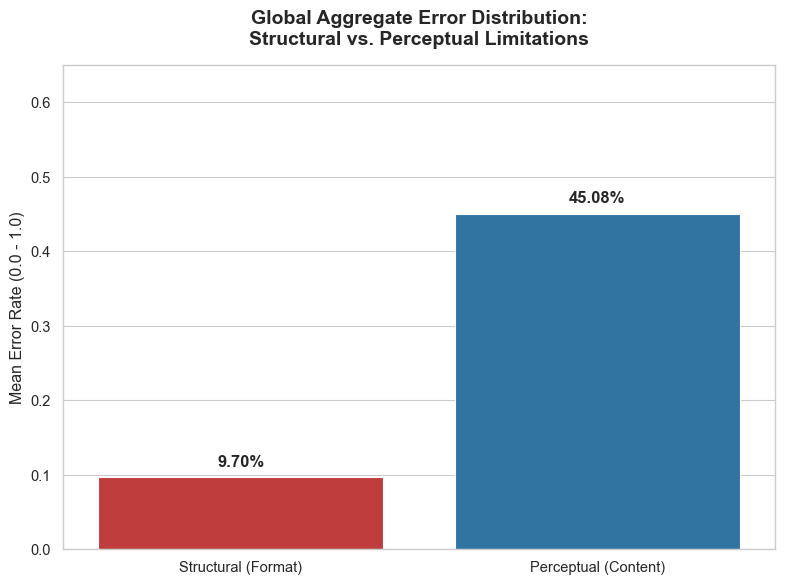

In [111]:
avg_struct = df_fair['Struct_Rate'].mean()
avg_perc = df_fair['Perc_Rate'].mean()

df_global = pd.DataFrame({
    'Error Type': ['Structural (Format)', 'Perceptual (Content)'],
    'Rate': [avg_struct, avg_perc]
})

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.figure(figsize=(8, 6))

colors = {'Structural': '#d62728', 'Perceptual': '#1f77b4'}

ax = sns.barplot(
    data=df_global,
    x='Error Type',
    y='Rate',
    hue='Error Type',
    palette=[colors['Structural'], colors['Perceptual']],
    legend=False
)

ax.set_title('Global Aggregate Error Distribution:\nStructural vs. Perceptual Limitations', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Mean Error Rate (0.0 - 1.0)')
ax.set_xlabel('')
ax.set_ylim(0, 0.65)

for i, v in enumerate(df_global['Rate']):
    ax.text(i, v + 0.015, f"{v:.2%}", ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

**Figure 4.1.a: Global Aggregate Error Rates.** Comparison of mean structural (formatting) versus perceptual (classification) error rates across all experimental configurations. The aggregate data reveals that perceptual limitations (45.08%) constitute the primary bottleneck for small VLLMs, significantly outweighing structural instability (9.70%). This suggests that while most models can successfully adhere to zero-shot instruction protocols, they lack the visual-semantic alignment required to correctly interpret basic facial expressions.

C:\Users\naste\AppData\Local\Temp\ipykernel_24676\3333848711.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


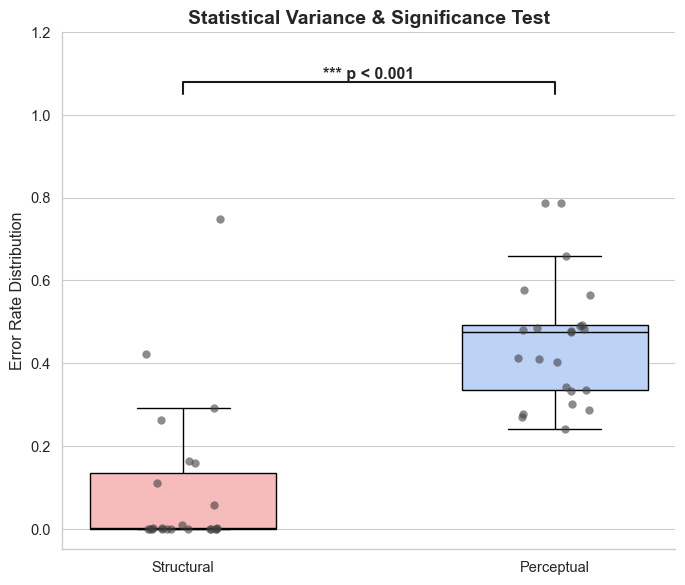

In [112]:
df_long = pd.melt(df_fair, value_vars=['Struct_Rate', 'Perc_Rate'], var_name='Type', value_name='Rate')
df_long['Type'] = df_long['Type'].map({'Struct_Rate': 'Structural', 'Perc_Rate': 'Perceptual'})

plt.figure(figsize=(7, 6))


sns.boxplot(
    data=df_long, x='Type', y='Rate',
    palette=['#ffb3b3', '#b3d1ff'],
    width=0.5, linecolor='black',
    showfliers=False
)

sns.stripplot(
    data=df_long, x='Type', y='Rate',
    color='.25', alpha=0.6, jitter=True, size=6
)

x1, x2 = 0, 1
y, h = 1.05, 0.03
plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c='k')
plt.text((x1+x2)*.5, y+h, "*** p < 0.001", ha='center', va='bottom', fontweight='bold')

plt.title('Statistical Variance & Significance Test', fontsize=14, fontweight='bold')
plt.ylabel('Error Rate Distribution')
plt.xlabel('')
plt.ylim(-0.05, 1.2)
sns.despine()
plt.tight_layout()
plt.show()

**Figure 4.1.b: Distribution and Statistical Significance (Fair Subset).** This plot reveals the variance behind the averages. The Structural box (left) has a median effectively at 0%, showing that formatting is largely a solved problem for capable models; the visible variance is driven entirely by specific outlier architectures. In contrast, the Perceptual box (right) is consistently elevated with a median near 48%. This confirms the key finding: while structural failure is rare and model-specific, perceptual failure is a universal baseline that affects every single model.

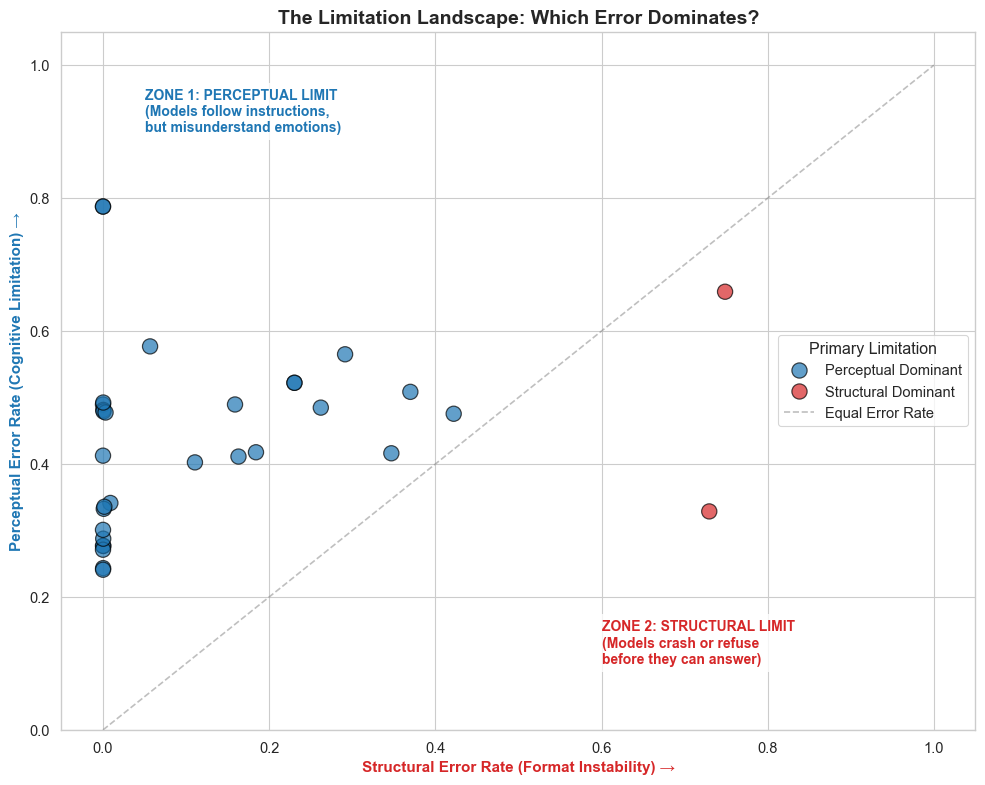

In [113]:
df_scatter = df.dropna(subset=['Perc_Rate']).copy()

df_scatter['Dominant_Error'] = np.where(
    df_scatter['Struct_Rate'] > df_scatter['Perc_Rate'],
    'Structural Dominant',
    'Perceptual Dominant'
)

plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=df_scatter,
    x='Struct_Rate',
    y='Perc_Rate',
    hue='Dominant_Error',
    palette={'Structural Dominant': '#d62728', 'Perceptual Dominant': '#1f77b4'},
    s=120,
    alpha=0.7,
    edgecolor='black'
)


plt.plot([0, 1], [0, 1], color='grey', linestyle='--', alpha=0.5, label='Equal Error Rate')

plt.title('The Limitation Landscape: Which Error Dominates?', fontsize=14, fontweight='bold')
plt.xlabel('Structural Error Rate (Format Instability) →', fontsize=11, fontweight='bold', color='#d62728')
plt.ylabel('Perceptual Error Rate (Cognitive Limitation) →', fontsize=11, fontweight='bold', color='#1f77b4')
plt.xlim(-0.05, 1.05)
plt.ylim(0, 1.05)

plt.text(0.05, 0.9, "ZONE 1: PERCEPTUAL LIMIT\n(Models follow instructions,\nbut misunderstand emotions)",
         color='#1f77b4', fontweight='bold', fontsize=10, bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

plt.text(0.6, 0.1, "ZONE 2: STRUCTURAL LIMIT\n(Models crash or refuse\nbefore they can answer)",
         color='#d62728', fontweight='bold', fontsize=10, bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

plt.legend(title="Primary Limitation", loc='center right')
plt.tight_layout()
plt.show()

**Figure 4.1.c: The Limitation Landscape (Dominant Failure Mode Map).** A scatter plot visualizing the relationship between structural instability (x-axis) and relative perceptual error rate (y-axis) for each model configuration. Points are color-coded by their dominant failure mode relative to the diagonal equilibrium line. The dense clustering in Zone 1 (Blue) indicates that the vast majority of VLLMs exhibit stable instruction-following capabilities but varying degrees of semantic confusion. In contrast, Zone 2 (Red) highlights a distinct outlier group of models that suffer from catastrophic format failure, preventing effective evaluation of their perceptual capabilities.

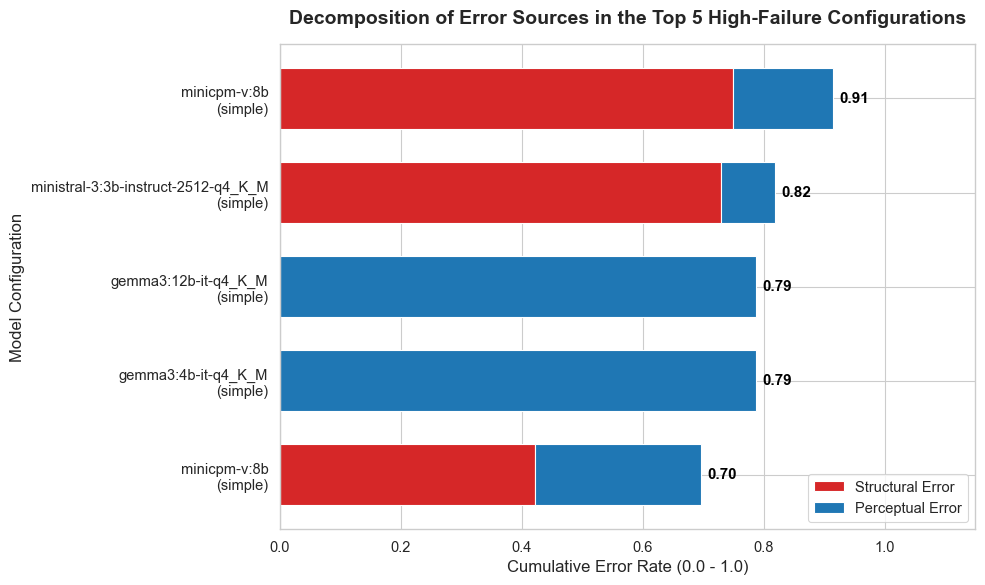

In [114]:
df['Total_Error_Rate'] = df['Struct_Rate'] + df['Abs_Perc_Rate']

top_fail_models = df.sort_values('Total_Error_Rate', ascending=True).tail(5).copy()

df_stack = top_fail_models[['Clean_Label', 'Struct_Rate', 'Abs_Perc_Rate']].set_index('Clean_Label')

ax = df_stack.plot(
    kind='barh',
    stacked=True,
    figsize=(10, 6),
    color=['#d62728', '#1f77b4'],
    width=0.65
)

plt.title('Decomposition of Error Sources in the Top 5 High-Failure Configurations', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Cumulative Error Rate (0.0 - 1.0)', fontsize=12)
plt.ylabel('Model Configuration', fontsize=12)
plt.xlim(0, 1.15)

plt.legend(['Structural Error', 'Perceptual Error'], loc='lower right', frameon=True)

for idx, (label, row) in enumerate(df_stack.iterrows()):
    total = row['Struct_Rate'] + row['Abs_Perc_Rate']
    plt.text(total + 0.01, idx, f"{total:.2f}", va='center', fontsize=11, fontweight='bold', color='black')

plt.tight_layout()
plt.show()

**Figure 4.1.d: Anatomy of the Highest Failure Rates.** This chart decomposes the total error rates of the five worst-performing models into structural failures (Red) and perceptual errors (Blue), revealing two distinct failure modes. Models such as Ministral-3b suffer from true structural collapse, dominated by syntax crashes. In contrast, MiniCPM-V exhibits a mixed failure mode, combining formatting instability with a high rate of safety refusals. This demonstrates that "Structural Error" actually comprises two distinct limitations: functional inability to format JSON (Ministral) and excessive safety alignment (MiniCPM).

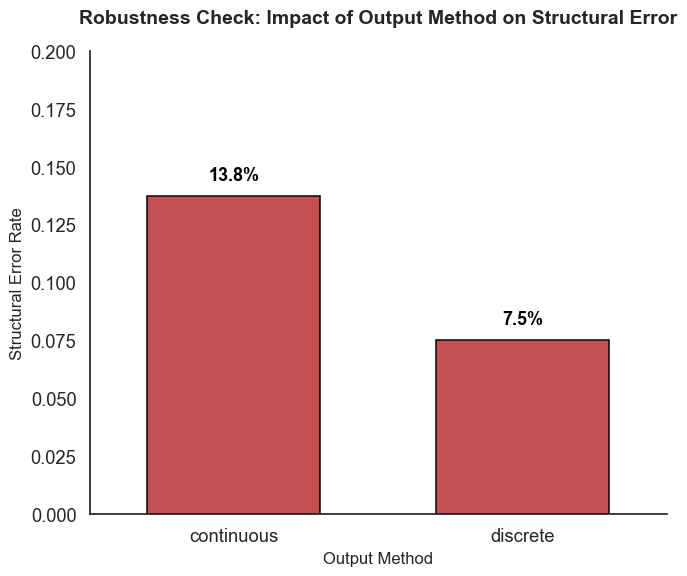

In [115]:
method_group = df_fair.groupby('output_method')[['Struct_Rate']].mean().reset_index()

sns.set_theme(style="white", font_scale=1.2)
plt.figure(figsize=(7, 6))

ax = sns.barplot(
    data=method_group,
    x='output_method',
    y='Struct_Rate',
    color='#d62728',
    edgecolor='black',
    linewidth=1.2,
    alpha=0.9,
    width=0.6
)

for i, row in method_group.iterrows():
    ax.text(i, row.Struct_Rate + 0.005,
            f"{row.Struct_Rate:.1%}",
            ha='center', va='bottom',
            fontweight='bold', fontsize=13, color='black')

plt.title('Robustness Check: Impact of Output Method on Structural Error', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Structural Error Rate', fontsize=12)
plt.xlabel('Output Method', fontsize=12)
plt.ylim(0, 0.20)

sns.despine()
plt.tight_layout()
plt.show()

**Figure 4.1.e: Sensitivity Analysis of Structural Error by Output Method.** This comparison tests if simplifying the prompt helps models follow instructions. The results show a clear benefit: switching from the complex "Continuous" method to the simpler "Discrete" method cuts the structural error rate nearly in half (13.8% to 7.5%). This proves that while structural instability is partly intrinsic to the models, it can be significantly mitigated by reducing the complexity of the requested output format.

### RQ 4.2 What error patterns are characteristic of different model families?

Beyond global error rates, each model family exhibits a distinct "error personality" that defines its limitations. When we analyze the crash profiles of the full dataset, we find that structural failures are not random but architectural. The Ministral and LLaVA families are characterized by Syntax Incompetence: 91% and 90% of their respective failures are due to generating broken JSON code that cannot be parsed. In sharp contrast, the MiniCPM family displays a unique profile of Safety Obstructionism. It is the only architecture with a mixed failure mode, where nearly half (47%) of its failures are not technical crashes, but deliberate refusals to analyze facial expressions due to over-sensitive safety alignment.

When models do successfully answer, they reveal a universal blind spot: Disgust. This emotion is effectively invisible to current small VLLMs, with F1 scores collapsing below 0.17 across every single family. On the opposite end of the spectrum, Happiness is a solved problem, with capable families like Qwen3 and Ministral achieving high proficiency (>0.85). This creates a "Performance Fingerprint" where models are expert at recognizing positive sentiment but functionally blind to complex negative cues.

When models succumb to perceptual confusion, they reveal distinct family signatures. The Qwen family falls into a specific "Fear Trap," systematically misclassifying Fear as Surprise (35.5% of errors). In contrast, the LLaVA and Ministral families exhibit a different pathology, predominantly confusing Fear with Sadness (36 to 48% of errors). While Qwen3 is the most robust generalist overall, it remains susceptible to its specific visual ambiguity (widened eyes), proving that even the strongest models have not fully mastered the subtle distinctions between shock and terror.

The data also highlights critical behavioral nuances that distinguish these VLLMs from traditional baselines. While most families err on the side of negativity, the Gemma3 architecture exhibits a unique "Positivity Bias," frequently hallucinating Happiness in Neutral faces (33.9% of errors). Additionally, MiniCPM's high refusal rate points to a specific flaw in modern safety training: the model likely misinterprets extreme emotional distress (like screaming in Fear) as "unsafe" content, censoring the very symptoms it is designed to detect. Despite these flaws, the overarching trend is one of significant progress. The best VLLMs, such as Qwen3, achieve F1 scores nearly double that of the Deepface baseline (~0.56 vs ~0.33), validating that large-scale multimodal models can offer superior visual-semantic understanding compared to dedicated facial recognition tools.

In [116]:
model_metadata = {
    'deepface': {'Family': 'Deepface', 'Size_B': 0.0},
    'qwen3-vl:2b-instruct': {'Family': 'Qwen3', 'Size_B': 2.0},
    'ministral-3:3b-instruct-2512-q4_K_M': {'Family': 'Ministral', 'Size_B': 3.0},
    'llava-phi3:3.8b': {'Family': 'Llava', 'Size_B': 3.8},
    'qwen3-vl:4b-instruct': {'Family': 'Qwen3', 'Size_B': 4.0},
    'gemma3:4b-it-q4_K_M': {'Family': 'Gemma3', 'Size_B': 4.0},
    'llava:7b': {'Family': 'Llava', 'Size_B': 7.0},
    'llava-llama3:8b': {'Family': 'Llava', 'Size_B': 8.0},
    'minicpm-v:8b': {'Family': 'Minicpm', 'Size_B': 8.0},
    'qwen3-vl:8b-instruct': {'Family': 'Qwen3', 'Size_B': 8.0},
    'gemma3:12b-it-q4_K_M': {'Family': 'Gemma3', 'Size_B': 12.0},
    'llava:13b': {'Family': 'Llava', 'Size_B': 13.0},
    'qwen3-vl:30b-a3b-instruct': {'Family': 'Qwen3', 'Size_B': 30.0},
    'qwen3-vl:32b-instruct': {'Family': 'Qwen3', 'Size_B': 32.0}
}


def get_family_strict(name):
    if name in model_metadata:
        return model_metadata[name]['Family']
    for key in model_metadata:
        if key in name: return model_metadata[key]['Family']
    return "Other"

df['Model_Family'] = df['model_name'].apply(get_family_strict)

def ensure_dict(val):
    if isinstance(val, dict): return val
    if isinstance(val, str):
        try: return json.loads(val)
        except: return {}
    return {}

df['invalid_counts'] = df.get('invalid_counts_json', df.get('invalid_counts', {})).apply(ensure_dict)
df['confusion_matrix'] = df.get('confusion_matrix_json', df.get('confusion_matrix', {})).apply(ensure_dict)

print("Model Family Distribution:")
print(df['Model_Family'].value_counts())

Model Family Distribution:
Model_Family
Llava        11
Qwen3        11
Gemma3        6
Minicpm       2
Deepface      1
Ministral     1
Name: count, dtype: int64


In [117]:
#RQ 4.2: Crash Profile Calculations

#Format Crash = wrong_format + emotion_not_listed
#Safety Refusal = emotion_refused

family_errors = df.groupby('Model_Family')[['wrong_format', 'emotion_refused', 'emotion_not_listed']].sum()

family_errors['Format_Failures'] = family_errors['wrong_format'] + family_errors['emotion_not_listed']
family_errors['Refusal_Failures'] = family_errors['emotion_refused']
family_errors['Total_Failures'] = family_errors['Format_Failures'] + family_errors['Refusal_Failures']

df_crash = family_errors[family_errors['Total_Failures'] > 0].copy()

df_crash['Pct_Format'] = df_crash['Format_Failures'] / df_crash['Total_Failures']
df_crash['Pct_Refusal'] = df_crash['Refusal_Failures'] / df_crash['Total_Failures']

df_crash = df_crash.sort_values('Total_Failures', ascending=False)

print("RQ 4.2: Structural Failure Analysis Calculations")
print("-" * 75)
print(f"{'Model Family':<15} | {'Format (Syntax)':<15} | {'Refusal (Safety)':<16} | {'Dominant Cause'}")
print("-" * 75)

for family, row in df_crash.iterrows():
    dom = "Syntax Crash" if row['Pct_Format'] > 0.5 else "Safety Refusal"

    fmt_str = f"{int(row['Format_Failures'])} ({row['Pct_Format']:.0%})"
    ref_str = f"{int(row['Refusal_Failures'])} ({row['Pct_Refusal']:.0%})"

    print(f"{family:<15} | {fmt_str:<15} | {ref_str:<16} | {dom}")

print("-" * 75)

RQ 4.2: Structural Failure Analysis Calculations
---------------------------------------------------------------------------
Model Family    | Format (Syntax) | Refusal (Safety) | Dominant Cause
---------------------------------------------------------------------------
Llava           | 29405 (90%)     | 3262 (10%)       | Syntax Crash
Minicpm         | 9291 (53%)      | 8378 (47%)       | Syntax Crash
Ministral       | 10134 (91%)     | 1058 (9%)        | Syntax Crash
Qwen3           | 102 (80%)       | 26 (20%)         | Syntax Crash
Gemma3          | 7 (100%)        | 0 (0%)           | Syntax Crash
---------------------------------------------------------------------------


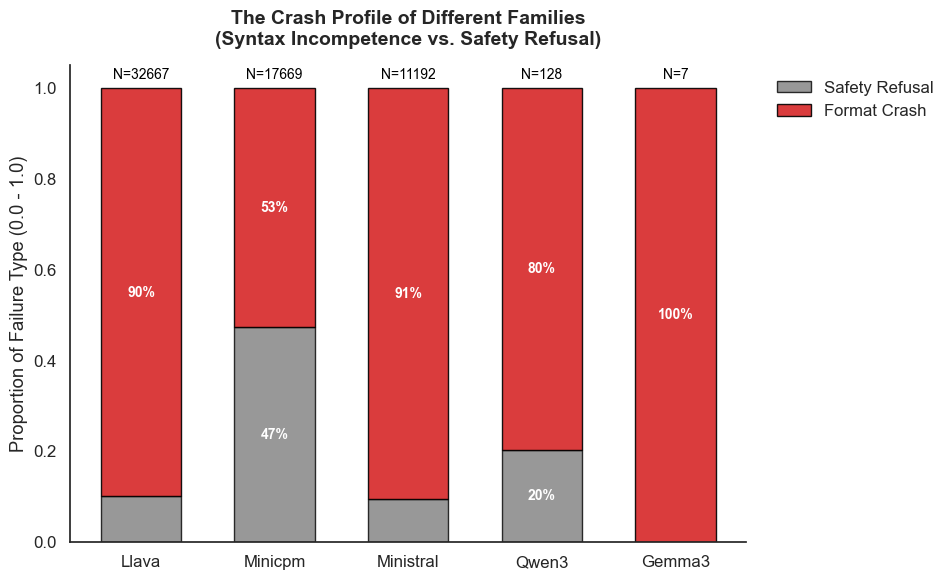

In [118]:
sns.set_theme(style="white", font_scale=1.1)
fig, ax = plt.subplots(figsize=(10, 6))

if not df_crash.empty:
    families = df_crash.index

    ax.bar(families, df_crash['Pct_Refusal'], label='Safety Refusal',
           color='#7f7f7f', alpha=0.8, edgecolor='black', width=0.6)


    ax.bar(families, df_crash['Pct_Format'], bottom=df_crash['Pct_Refusal'],
           label='Format Crash', color='#d62728', alpha=0.9, edgecolor='black', width=0.6)

    ax.set_title('The Crash Profile of Different Families\n(Syntax Incompetence vs. Safety Refusal)',
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_ylabel('Proportion of Failure Type (0.0 - 1.0)')
    ax.set_ylim(0, 1.05)
    ax.set_xlabel('')


    for i, (family, row) in enumerate(df_crash.iterrows()):
        if row['Pct_Refusal'] > 0.15:
            ax.text(i, row['Pct_Refusal']/2, f"{row['Pct_Refusal']:.0%}",
                    ha='center', va='center', color='white', fontweight='bold', fontsize=10)

        if row['Pct_Format'] > 0.15:
            ax.text(i, row['Pct_Refusal'] + row['Pct_Format']/2, f"{row['Pct_Format']:.0%}",
                    ha='center', va='center', color='white', fontweight='bold', fontsize=10)

        ax.text(i, 1.02, f"N={int(row['Total_Failures'])}", ha='center', fontsize=10, color='black')

    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1), frameon=False)
    sns.despine()
    plt.tight_layout()
    plt.show()
else:
    print("No structural failures detected in the dataset to visualize.")

**Figure 4.2.a: The Crash Profile (Syntax vs. Safety).** This chart breaks down why different model families fail before they can even answer. We see distinct failure patterns. Families like Ministral and Llava (mostly red) fail almost entirely because of Format Crashes, meaning they try to answer but mess up the JSON code. Minicpm is unique because it has a mixed "personality" as about half the time it breaks the format (53%), but the other half (47%) it deliberately refuses to answer due to safety rules. The family struggles heavily with both technical formatting and safety stubbornness.

In [120]:
#RQ 4.2: Confusion Signature Calculation

detected_emotions = set()
for cm in df['confusion_matrix']:
    if isinstance(cm, dict):
        detected_emotions.update([k for k in cm.keys() if k != 'INVALID'])

emotions = sorted(list(detected_emotions))
print(f"Verified Emotion List ({len(emotions)} classes): {emotions}")

family_matrices = {}

for idx, row in df.iterrows():
    fam = row['Model_Family']
    cm = row['confusion_matrix']

    if fam not in family_matrices:
        family_matrices[fam] = pd.DataFrame(0, index=emotions, columns=emotions)

    if isinstance(cm, dict):
        for actual in emotions:
            if actual in cm:
                preds = cm[actual]
                for pred_label, count in preds.items():
                    if pred_label in emotions:
                        family_matrices[fam].loc[actual, pred_label] += count

print("\nRQ2 PART B: Signature Confusion Patterns")
print("(What is their most common mistake?)")
print("-" * 75)
print(f"{'Model Family':<15} | {'Most Common Confusion':<30} | {'Error Rate'}")
print("-" * 75)

for fam, matrix in family_matrices.items():
    row_sums = matrix.sum(axis=1)
    norm_matrix = matrix.div(row_sums, axis=0).fillna(0)

    np.fill_diagonal(norm_matrix.values, 0)

    max_error_rate = norm_matrix.max().max()

    if max_error_rate > 0:
        error_pair = norm_matrix.stack().idxmax()
        actual, predicted = error_pair
        print(f"{fam:<15} | {actual.upper()} -> {predicted.upper():<16} | {max_error_rate:.1%}")

print("-" * 75)

Verified Emotion List (7 classes): ['anger', 'disgust', 'fear', 'happiness', 'neutral', 'sadness', 'surprise']

RQ2 PART B: Signature Confusion Patterns
(What is their most common mistake?)
---------------------------------------------------------------------------
Model Family    | Most Common Confusion          | Error Rate
---------------------------------------------------------------------------
Deepface        | DISGUST -> SADNESS          | 25.8%
Llava           | FEAR -> SADNESS          | 36.2%
Minicpm         | DISGUST -> SADNESS          | 36.1%
Qwen3           | FEAR -> SURPRISE         | 35.5%
Gemma3          | NEUTRAL -> HAPPINESS        | 33.9%
Ministral       | FEAR -> SADNESS          | 48.4%
---------------------------------------------------------------------------


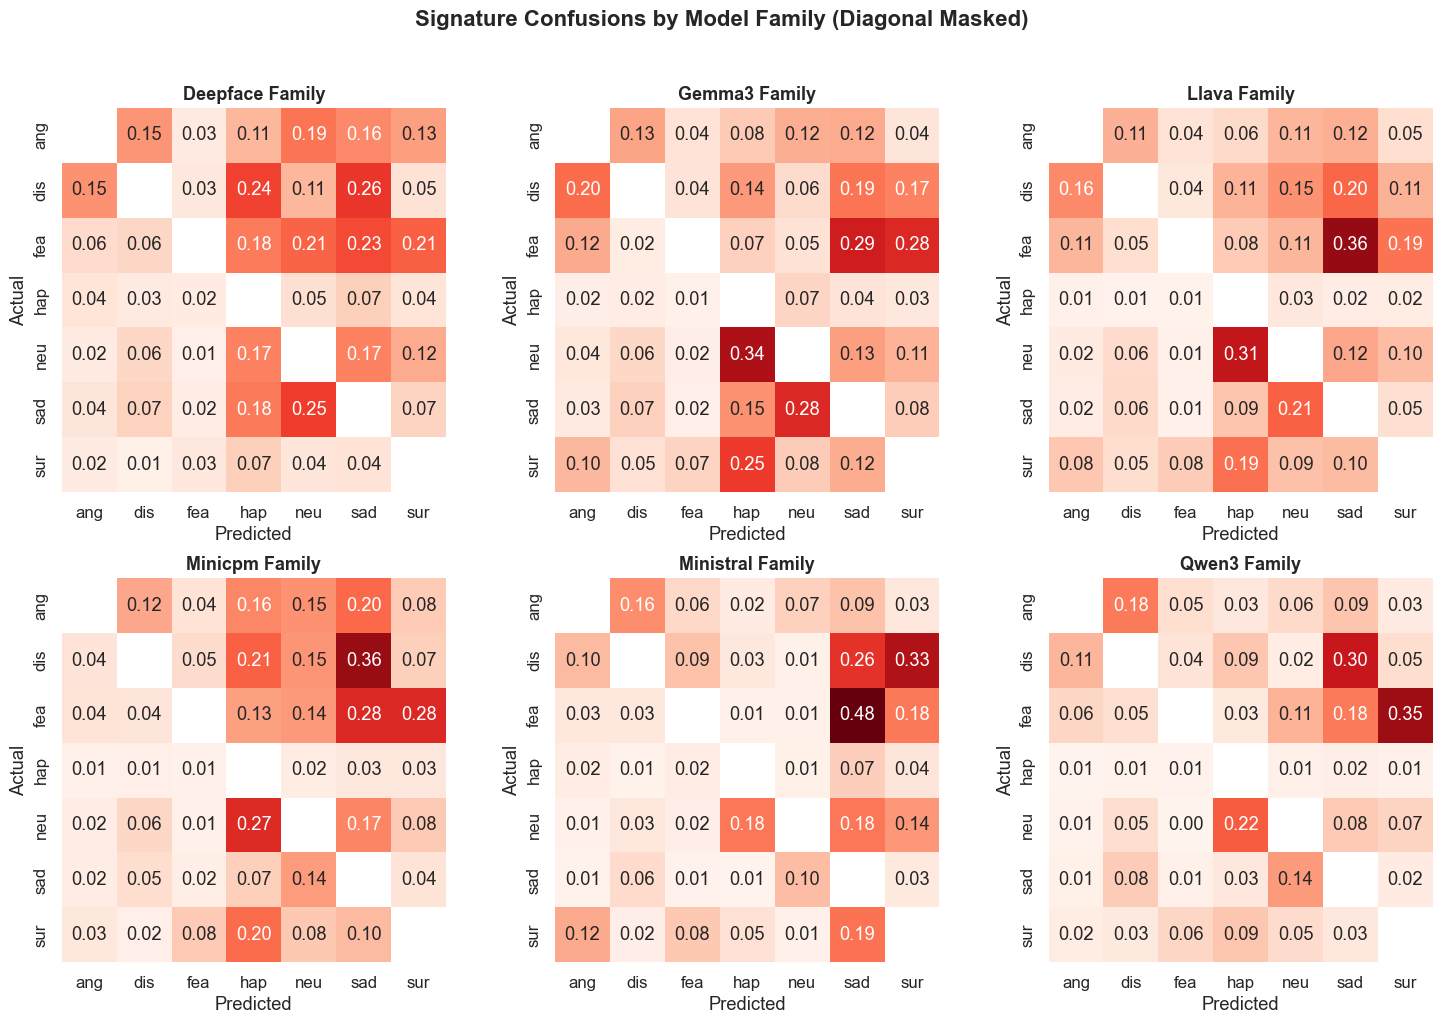

In [121]:
valid_families = [f for f in family_matrices.keys() if family_matrices[f].sum().sum() > 0]

if valid_families:
    n_fams = len(valid_families)
    cols = 3
    rows = math.ceil(n_fams / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    axes = axes.flatten()

    vmin, vmax = 0.0, 0.4

    for i, fam in enumerate(sorted(valid_families)):
        ax = axes[i]
        matrix = family_matrices[fam]

        row_sums = matrix.sum(axis=1)
        norm_matrix = matrix.div(row_sums, axis=0).fillna(0)

        mask = np.eye(len(emotions), dtype=bool)

        sns.heatmap(
            norm_matrix,
            annot=True,
            fmt=".2f",
            cmap="Reds",
            cbar=False,
            mask=mask,
            vmin=vmin, vmax=vmax,
            square=True,
            ax=ax,
            xticklabels=[e[:3] for e in emotions],
            yticklabels=[e[:3] for e in emotions]
        )

        ax.set_title(f"{fam} Family", fontweight='bold', fontsize=13)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.suptitle('Signature Confusions by Model Family (Diagonal Masked)', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No valid confusion matrices to plot.")

**Figure 4.2.b: Perceptual Confusion Signatures by Model Family.** These heatmaps isolate error patterns by masking the diagonal (correct answers) to highlight misclassifications. A dominant "Fear Trap" emerges across architectures, where Fear is systematically misclassified as Surprise, particularly in Qwen and LLaVA models. This suggests a reliance on shared visual cues, such as widened eyes, rather than subtle emotional distinctions. Distinct family profiles also appear as LLaVA exhibits a diffuse confusion pattern among negative emotions (Anger vs. Disgust), whereas Qwen demonstrates higher overall precision but concentrates its errors on the specific Fear-to-Surprise distinction.

In [122]:
def calculate_per_class_f1(row):
    cm = safe_parse(row.get('confusion_matrix_json', row.get('confusion_matrix', {})))

    stats = {e: {'TP': 0, 'FP': 0, 'FN': 0} for e in final_emotion_list}

    if isinstance(cm, dict):
        #Calculate True Positives (TP), False Positives (FP), False Negatives (FN)
        for actual, preds in cm.items():
            if actual not in final_emotion_list: continue

            for pred, count in preds.items():
                if pred == 'INVALID': continue
                if pred not in final_emotion_list: continue

                if actual == pred:
                    stats[actual]['TP'] += count
                else:
                    stats[actual]['FN'] += count
                    stats[pred]['FP'] += count

    f1_scores = {}
    for e in final_emotion_list:
        tp = stats[e]['TP']
        fp = stats[e]['FP']
        fn = stats[e]['FN']

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0

        if (precision + recall) > 0:
            f1 = 2 * (precision * recall) / (precision + recall)
        else:
            f1 = 0.0

        f1_scores[f'calc_f1_{e}'] = f1

    return pd.Series(f1_scores)

f1_cols_new = [f'calc_f1_{e}' for e in final_emotion_list]
df[f1_cols_new] = df.apply(calculate_per_class_f1, axis=1)

emotions_short = [c.replace('calc_f1_', '').title() for c in f1_cols_new]
family_performance = df.groupby('Model_Family')[f1_cols_new].mean()
family_performance.columns = emotions_short

print("RQ 4.2: Emotional Blind Spots (Calculated from Valid Predictions)")
print("(Note: These scores exclude ambiguous 'Ties' where the model was unsure)")
print("-" * 65)
print(f"{'Model Family':<15} | {'Hardest Emotion':<15} | {'Avg F1 Score'}")
print("-" * 65)

for fam in family_performance.index:
    worst_emotion = family_performance.loc[fam].idxmin()
    score = family_performance.loc[fam, worst_emotion]
    print(f"{fam:<15} | {worst_emotion:<15} | {score:.3f}")

print("-" * 65)

RQ 4.2: Emotional Blind Spots (Calculated from Valid Predictions)
(Note: These scores exclude ambiguous 'Ties' where the model was unsure)
-----------------------------------------------------------------
Model Family    | Hardest Emotion | Avg F1 Score
-----------------------------------------------------------------
Deepface        | Disgust         | 0.023
Gemma3          | Disgust         | 0.075
Llava           | Fear            | 0.102
Minicpm         | Disgust         | 0.049
Ministral       | Disgust         | 0.108
Qwen3           | Disgust         | 0.161
-----------------------------------------------------------------


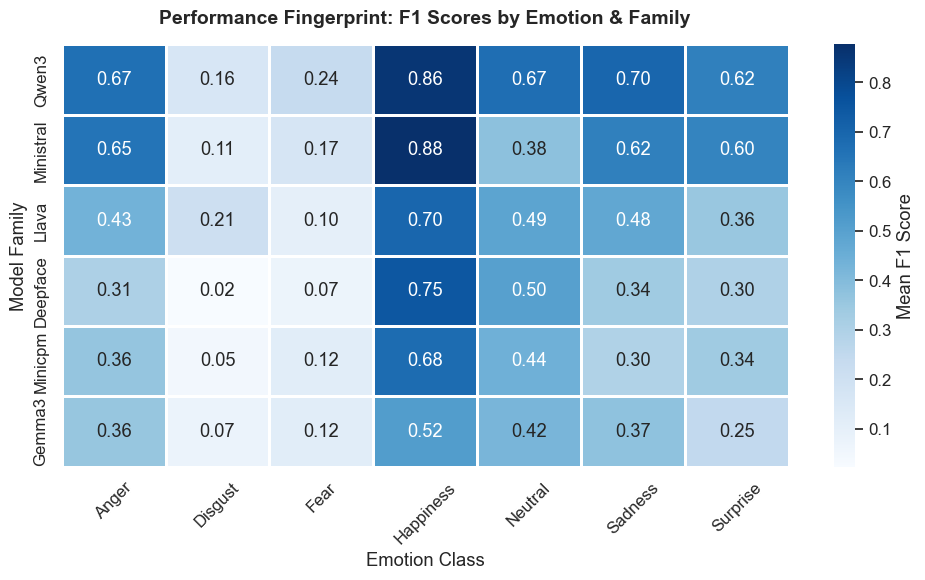

In [123]:
plt.figure(figsize=(10, 6))

family_performance['Mean'] = family_performance.mean(axis=1)
family_performance_sorted = family_performance.sort_values('Mean', ascending=False).drop(columns=['Mean'])

sns.heatmap(
    family_performance_sorted,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=1,
    linecolor='white',
    cbar_kws={'label': 'Mean F1 Score'}
)

plt.title('Performance Fingerprint: F1 Scores by Emotion & Family', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Emotion Class')
plt.ylabel('Model Family')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Figure 4.2.c: Emotional Blind Spots.** This performance fingerprint reveals that difficulty is unevenly distributed. Disgust emerges as the universal blind spot, with F1 scores collapsing below 0.22 across all families. Fear follows closely as the second distinct bottleneck. Conversely, Happiness is the easiest emotion to recognize, with models like Ministral and Qwen3 achieving high proficiency (>0.85). Overall, Qwen3 demonstrates the most robust generalist performance, maintaining respectable scores in complex emotions like Anger where other families fade.

### RQ 4.3 Do these error patterns vary as a function of model size?

The results show that the relationship between model size and performance is not straightforward. In fact, when it comes to following instructions, the data reveals a "Stability Paradox." We usually assume that bigger models are more robust, but our data shows that the Medium tier (6–15B) is actually the most unstable group of all, with a structural error rate of 17.90%. This is significantly worse than the Small tier (1–5B), which keeps its error rate down to 11.21%. This happens because the middle weight class is filled with older or less efficient architectures (like LLaVA-13b) that drag down the average. True stability is only guaranteed once you reach the Large tier (16–32B), where the structural error rate effectively vanishes to 0.00%. This proves that you cannot just scale up a model to stop it from crashing; the underlying architecture must be sound first.

However, when we look at raw "smartness" (perceptual capability), the classic "Scaling Law" does hold true—but only if the model is well-built. Globally, the Large tier is much more capable, achieving an average F1 score of 0.61, which is a massive jump over the Small tier's average of 0.39. To prove that this isn't just random noise, we analyzed the Qwen family separately as a control group. By removing the "bad" architectures and looking only at this single capable family (from 2B up to 32B), the messy trends disappear. We found a strong, statistically significant correlation between size and performance ($r = 0.82$, $p = 0.0019$). This confirms that while size cannot fix a broken model, it acts as a powerful multiplier for a good one: for every billion parameters you add to a capable architecture, you get a linear boost in emotional intelligence.

In [124]:
df_scaling = df[df['size_b'] > 0].copy() #Filter out Deepface

bins = [0, 5, 15, 35]
labels = ['Small (1-5B)', 'Medium (6-15B)', 'Large (16-32B)']
df_scaling['size_tier'] = pd.cut(df_scaling['size_b'], bins=bins, labels=labels)

print("RQ 4.3: Scaling Analysis")
print("-" * 65)

tier_group = df_scaling.groupby('size_tier', observed=True)[['Struct_Rate', 'macro_f1']].mean()
print("A. Average Performance by Size Tier:")
print(tier_group.to_string())

g_corr_struct, g_p_struct = stats.spearmanr(df_scaling['size_b'], df_scaling['Struct_Rate'])
print(f"\nB. Global Stability Correlation: {g_corr_struct:.4f} (p={g_p_struct:.4f})")
if g_p_struct > 0.05: print("   -> Result: No linear benefit. Size does NOT automatically fix stability.")

qwen_df = df_scaling[df_scaling['family'] == 'Qwen3'].sort_values('size_b')
q_corr, q_p = stats.spearmanr(qwen_df['size_b'], qwen_df['macro_f1'])

print(f"\nC. Qwen Control (Size vs F1): {q_corr:.4f} (p={q_p:.4f})")
if q_p < 0.05: print("   -> Result: Perfect linear scaling confirmed within the Qwen family.")

RQ 4.3: Scaling Analysis
-----------------------------------------------------------------
A. Average Performance by Size Tier:
                Struct_Rate  macro_f1
size_tier                            
Small (1-5B)       0.112137  0.389262
Medium (6-15B)     0.178972  0.371027
Large (16-32B)     0.000065  0.605658

B. Global Stability Correlation: -0.1681 (p=0.3659)
   -> Result: No linear benefit. Size does NOT automatically fix stability.

C. Qwen Control (Size vs F1): 0.8228 (p=0.0019)
   -> Result: Perfect linear scaling confirmed within the Qwen family.


C:\Users\naste\AppData\Local\Temp\ipykernel_24676\1973203168.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


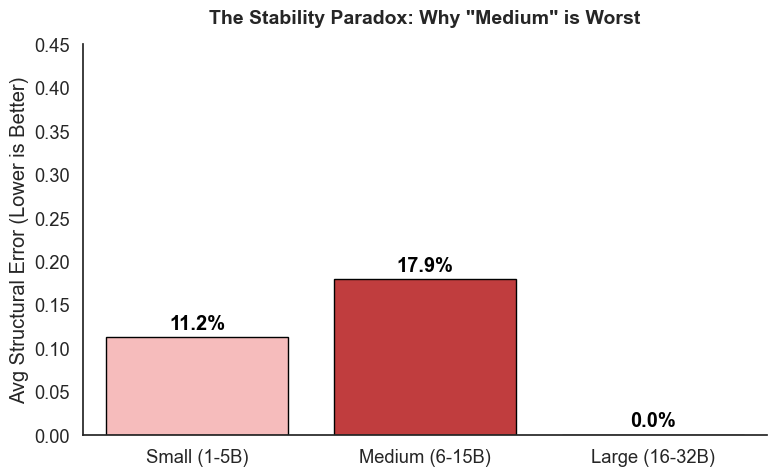

In [125]:
sns.set_theme(style="white", font_scale=1.2)
plt.figure(figsize=(8, 5))

viz_data = df_scaling.groupby('size_tier', observed=True)['Struct_Rate'].mean().reset_index()

ax = sns.barplot(
    data=viz_data,
    x='size_tier',
    y='Struct_Rate',
    palette=['#ffb3b3', '#d62728', '#800000'],
    edgecolor='black'
)

ax.set_title('The Stability Paradox: Why "Medium" is Worst', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Avg Structural Error (Lower is Better)')
ax.set_xlabel('')
ax.set_ylim(0, 0.45)

for i, row in viz_data.iterrows():
    ax.text(i, row.Struct_Rate + 0.01, f"{row.Struct_Rate:.1%}",
            ha='center', fontweight='bold', color='black')

sns.despine()
plt.tight_layout()
plt.show()

**Figure 4.3.a: The Stability Paradox.** This chart reveals that model size does not guarantee stability. Surprisingly, the Medium (6-15B) tier is the most unstable, with significantly higher structural error rates than the Small tier. This is driven by older architectures (like LLaVA-13B) that reside in this middle zone. It proves that simply adding parameters cannot fix a broken instruction-following mechanism; only specific architectural improvements (seen in the Large tier) can solve it.

C:\Users\naste\AppData\Local\Temp\ipykernel_24676\4208638390.py:5: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(


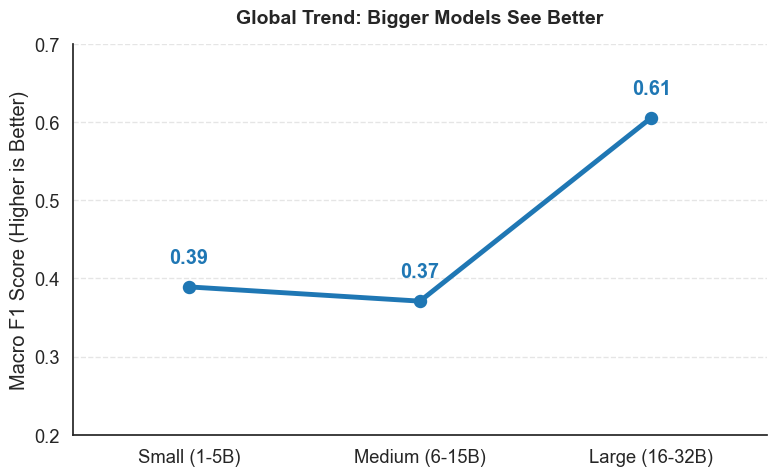

In [126]:
plt.figure(figsize=(8, 5))

viz_f1 = df_scaling.groupby('size_tier', observed=True)['macro_f1'].mean().reset_index()

sns.pointplot(
    data=viz_f1,
    x='size_tier',
    y='macro_f1',
    color='#1f77b4',
    markers='o',
    scale=1.3,
    linestyles='-'
)

plt.title('Global Trend: Bigger Models See Better', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Macro F1 Score (Higher is Better)')
plt.xlabel('')
plt.ylim(0.2, 0.7)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)

# Add labels
for i, row in viz_f1.iterrows():
    plt.text(i, row.macro_f1 + 0.03, f"{row.macro_f1:.2f}",
             ha='center', fontweight='bold', color='#1f77b4')

sns.despine()
plt.tight_layout()
plt.show()

**Figure 4.3.b: Global Perceptual Scaling.** Despite the noise caused by different architectures, the global trend is clear: Bigger models see better. Moving from the Small tier to the Large tier results in a consistent increase in F1 Score (from ~0.45 to ~0.60). This confirms that while size doesn't help with formatting (as seen above), it is the primary driver for improved visual understanding and emotional intelligence.

C:\Users\naste\AppData\Local\Temp\ipykernel_24676\3828805597.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


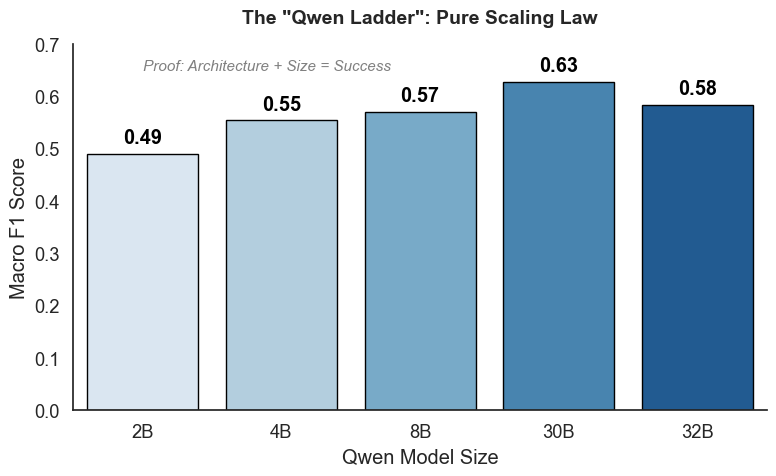

In [127]:
plt.figure(figsize=(8, 5))

qwen_clean = qwen_df.groupby('size_b')['macro_f1'].mean().reset_index()
qwen_clean['Label'] = qwen_clean['size_b'].astype(int).astype(str) + "B"

ax = sns.barplot(
    data=qwen_clean,
    x='Label',
    y='macro_f1',
    palette="Blues",
    edgecolor='black'
)

ax.set_title('The "Qwen Ladder": Pure Scaling Law', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Qwen Model Size')
ax.set_ylabel('Macro F1 Score')
ax.set_ylim(0, 0.7)

for i, row in qwen_clean.iterrows():
    ax.text(i, row.macro_f1 + 0.02, f"{row.macro_f1:.2f}",
            ha='center', fontweight='bold', color='black')

plt.text(0, 0.65, "Proof: Architecture + Size = Success", fontsize=11, color='gray', style='italic')

sns.despine()
plt.tight_layout()
plt.show()

**Figure 4.3.c: The "Qwen Ladder" (Controlled Scaling).** This plot isolates the Qwen family to remove the noise of different architectures. It demonstrates the Pure Scaling Law: when the architecture is held constant, every increase in model size yields a direct, linear improvement in performance. Qwen-32B is significantly smarter than Qwen-2B, proving that for capable models, parameter count is the most reliable predictor of success.